In [2]:
''' imports libraries '''

# misc
import pandas as pd # Import Pandas for data manipulation using dataframes
import numpy as np # Import Numpy for data statistical analysis 
import matplotlib.pyplot as plt # Import matplotlib for data visualisation
import seaborn as sns
import random

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Keras
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import TensorBoard

# FEATURE ENGINEERING

In [4]:
''' defines functions for feature transformation '''

def one_hot_encode(feature):
    global df_enabled

    if not feature in df_enabled.columns: 
        print(f'WARN: tried to one-hot encode missing feature {feature}')
        return

    # prefix appends feature name to each categorie's column
    one_hot = pd.get_dummies(df_enabled[feature], prefix=feature)

    # adds one boolean column for each discrete value
    df_enabled = pd.concat([df_enabled, one_hot], axis=1)

    # drops previous column
    df_enabled.drop(feature, axis=1, inplace=True)


# uses mean normalisation
def normalise(feature):
    global df_enabled

    if not feature in df_enabled.columns: 
        print(f'WARN: tried to normalise missing feature {feature}')
        return

    feature_row = df_enabled[feature]
    df_enabled.loc[:, f'{feature}_normalised'] = (feature_row - feature_row.mean()) / (feature_row.max() - feature_row.min())
    df_enabled.drop(feature, axis=1, inplace=True)
    

In [5]:
''' dataframes creation for both training and testing datasets '''

df = pd.read_csv('data/dataset_sample.csv',sep=',')

# selects features
enabled_features = [
    'merchant_category', 
    'merchant_type', 
    'country', 
    'currency', 
    'city_size', 
    'amount', 
    'distance_from_home', 
    'transaction_hour',
    'weekend_transaction'
]
df_enabled = df[enabled_features].copy()

# normalises features
for feature in ['amount', 'distance_from_home', 'transaction_hour']:
    normalise(feature)

# one-hot encodes features
for feature in ['merchant_category', 'merchant_type', 'country', 'currency', 'city_size']:
    one_hot_encode(feature)

# adds the label to the last position
df_enabled['is_fraud'] = df['is_fraud']

# prints overview
print(df_enabled.shape)
# print(df_enabled.columns)
print('Missing values count:', df_enabled.isnull().sum().sum())

# note - random_state is the seed for shuffling
df_train, df_test = train_test_split(df_enabled, test_size=0.3, random_state=42)

(10000, 55)
Missing values count: 0


In [6]:
df_train.head()

,weekend_transaction,amount_normalised,distance_from_home_normalised,transaction_hour_normalised,merchant_category_Education,merchant_category_Entertainment,merchant_category_Gas,merchant_category_Grocery,merchant_category_Healthcare,merchant_category_Restaurant,...,currency_GBP,currency_JPY,currency_MXN,currency_NGN,currency_RUB,currency_SGD,currency_USD,city_size_large,city_size_medium,is_fraud
9069,True,-0.009884,-0.3212,-0.179674,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2603,False,-0.009966,0.6788,-0.353587,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,True
7738,False,-0.006370,0.6788,-0.266630,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,True,False
1579,False,-0.009852,0.6788,-0.440543,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
5058,False,-0.009819,0.6788,0.081196,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,True,True


In [7]:
df_test.shape

(3000, 55)

In [8]:
# Create training and testing arrays
training = np.array(df_train, dtype = 'float32')
testing = np.array(df_test, dtype='float32')

In [9]:
training.shape

(7000, 55)

# TRAINING THE MODEL

In [11]:
# Prepare the training and testing dataset 
X_train = training[:,:-1]
y_train = training[:,-1:]

X_test = testing[:,:-1]
y_test = testing[:,-1:]

In [12]:
# validation dataset that might used to help the model to generalize
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, test_size = 0.2, random_state = 32415)

In [13]:
X_train.shape

(5600, 54)

In [14]:
X_test.shape

(3000, 54)

In [15]:
X_validate.shape

(1400, 54)

In [16]:
print(y_test.sum())

617.0


In [17]:
model = Sequential([
    Dense(90, activation='relu'),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss=keras.losses.binary_crossentropy, metrics=['accuracy'])
epochs = 10
batch_size = 128

# note - reduces false negatives
class_weights = compute_class_weight('balanced', classes=np.unique(y_validate), y=y_validate[:, 0])
class_weights_dict = dict(enumerate(class_weights))

history = model.fit(
    X_train, 
    y_train, 
    validation_data=(X_validate, y_validate), 
    epochs=epochs, batch_size=batch_size, 
    class_weight=class_weights_dict
)

Epoch 1/10


2024-11-16 14:31:48.030939: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


44/44 [==============================] - 0s 2ms/step - loss: 0.5181 - accuracy: 0.8064 - val_loss: 0.3374 - val_accuracy: 0.8786
Epoch 2/10
44/44 [==============================] - 0s 958us/step - loss: 0.3142 - accuracy: 0.8734 - val_loss: 0.3132 - val_accuracy: 0.8779
Epoch 3/10
44/44 [==============================] - 0s 1ms/step - loss: 0.2964 - accuracy: 0.8818 - val_loss: 0.3293 - val_accuracy: 0.8679
Epoch 4/10
44/44 [==============================] - 0s 1ms/step - loss: 0.2884 - accuracy: 0.8809 - val_loss: 0.3039 - val_accuracy: 0.8779
Epoch 5/10
44/44 [==============================] - 0s 1ms/step - loss: 0.2843 - accuracy: 0.8866 - val_loss: 0.2937 - val_accuracy: 0.8807
Epoch 6/10
44/44 [==============================] - 0s 1ms/step - loss: 0.2815 - accuracy: 0.8771 - val_loss: 0.2838 - val_accuracy: 0.8850
Epoch 7/10
44/44 [==============================] - 0s 1ms/step - loss: 0.2824 - accuracy: 0.8848 - val_loss: 0.2926 - val_accuracy: 0.8793
Epoch 8/10
44/44 [===========

# EVALUATING THE MODEL

In [19]:
print('Last validation accuracy:')
last_epoch_accuracy = history.history['val_accuracy'][-1]
print(f'{last_epoch_accuracy:.4f}')
print('Test accuracy:')
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

Last validation accuracy:
0.8821
Test accuracy:
94/94 [==============================] - 0s 310us/step - loss: 0.3017 - accuracy: 0.8760


In [20]:
y_pred = model.predict(X_test)
predicted_classes = (y_pred > 0.5).astype(int)

94/94 [==============================] - 0s 268us/step


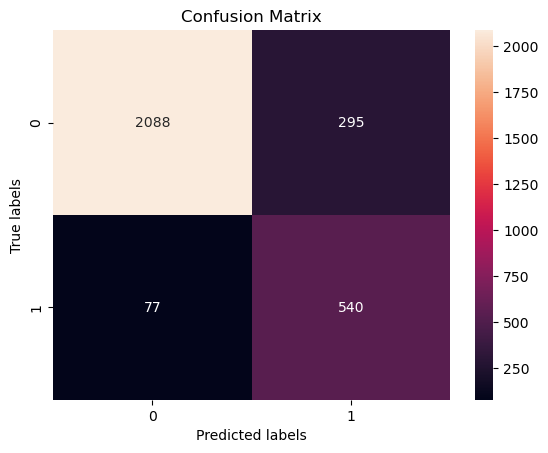

Correct guesses amt: 2628.0


In [21]:
# use seaborn library to plot the confusion matrix 
matrix = confusion_matrix(y_test, predicted_classes)

sns.heatmap(matrix, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Sum the diagonal element to get the total true correct values
identity = np.eye(matrix.shape[0])
diagonal = np.multiply(matrix, identity)
sum = np.sum(diagonal)
print(f'Correct guesses amt: {sum}')

In [22]:
target_names = ["Class {}".format(i) for i in range(2)]

print(classification_report(y_test, predicted_classes, target_names = target_names))

              precision    recall  f1-score   support

     Class 0       0.96      0.88      0.92      2383
     Class 1       0.65      0.88      0.74       617

    accuracy                           0.88      3000
   macro avg       0.81      0.88      0.83      3000
weighted avg       0.90      0.88      0.88      3000

